In [64]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import string

import nltk
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('averaged_perceptron_tagger')
nltk.download('averaged_perceptron_tagger_eng')

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer, PorterStemmer
from nltk.tokenize import word_tokenize
from nltk import pos_tag

from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from scipy.sparse import hstack

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Embedding, LSTM, GlobalAveragePooling1D
from tensorflow.keras.preprocessing.text import Tokenizer as KerasTokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import EarlyStopping



print('Setup is ready!')

Setup is ready!


[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/domiendarmont/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     /Users/domiendarmont/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     /Users/domiendarmont/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     /Users/domiendarmont/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /Users/domiendarmont/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /Users/domiendarmont/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date

In [65]:
df = pd.read_csv('/Users/domiendarmont/Desktop/Ironhack/lab_week4_NLP/TEST:W4_project_NLP/training_data_fixed.csv')
df.head()


,label,text
0,0,donald trump sends out embarrassing new year‚s...
1,0,drunk bragging trump staffer started russian c...
2,0,sheriff david clarke becomes an internet joke ...
3,0,trump is so obsessed he even has obama‚s name ...
4,0,pope francis just called out donald trump duri...


In [66]:
print('Shape:', df.shape)
print('Kolommen:', df.columns.tolist())
print('Datatypes:')
print(df.dtypes)
print('Lege waarden:')
print(df.isnull().sum())


Shape: (34152, 2)
Kolommen: ['label', 'text']
Datatypes:
label    int64
text       str
dtype: object
Lege waarden:
label    0
text     0
dtype: int64


In [67]:
X_train, X_test, y_train, y_test = train_test_split(
    df["text"],
    df["label"],
    test_size=0.2,
    random_state=42
)

print("Train:", X_train.shape)
print("Test: ", X_test.shape)


Train: (27321, 1)
Test:  (6831, 1)


In [68]:
stop_words = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()
stemmer    = PorterStemmer()

def preprocess(text):
    # 1. HTML cleaning - uitgecommentarieerd: data bevat geen HTML
    # text = re.sub(r"<(script|style).*?>.*?</\1>", "", text, flags=re.DOTALL)
    # text = re.sub(r"<!--.*?-->", "", text, flags=re.DOTALL)
    # text = re.sub(r"<.*?>", "", text)

    # 2. Prefixed b - uitgecommentarieerd: data bevat geen bytes strings
    # text = re.sub(r"^b\s+", "", text)

    # 3. Lowercase - uitgecommentarieerd: data is al lowercase
    # text = text.lower()

    # 4. Special characters
    text = re.sub(r"[^a-zA-Z\s]", " ", text)

    # 5. Numbers
    text = re.sub(r"\d+", " ", text)

    # 6. Losse letters
    text = re.sub(r"\b[a-zA-Z]\b", " ", text)
    text = re.sub(r"^\s*[a-zA-Z]\s+", " ", text)

    # 7. Dubbele spaties
    text = re.sub(r"\s+", " ", text).strip()

    # 8. Tokenization - MOET voor stopwords en lemmatization!
    tokens = word_tokenize(text)

    # 9. Punctuation removal
    tokens = [w for w in tokens if w not in string.punctuation]

    # 10. Stopwords - MOET na lowercase EN na tokenization!
    tokens = [w for w in tokens if w not in stop_words]

    # 11. Lemmatization - werkt op individuele tokens!
    tokens = [lemmatizer.lemmatize(w) for w in tokens]

    # 12. Terug samenvoegen naar string
    return " ".join(tokens)

# Toepassen - apart op train en test
X_train = X_train.apply(preprocess)
X_test  = X_test.apply(preprocess)

print("Na preprocessing:")
print(X_train.iloc[0])


Na preprocessing:
text    
Name: 8891, dtype: str


In [69]:
tfidf = TfidfVectorizer(
    max_features=20000,
    ngram_range=(1,2)
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf  = tfidf.transform(X_test)

print("TF-IDF shape:", X_train_tfidf.shape)


TF-IDF shape: (27321, 20000)


In [70]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)
model.fit(X_train_tfidf, y_train)

y_pred = model.predict(X_test_tfidf)

In [71]:
# Train accuracy Logistic Regression with lemmatization and TF-IDF
y_train_pred = model.predict(X_train_tfidf)
train_acc = accuracy_score(y_train, y_train_pred)

# Test accuracy
y_test_pred = model.predict(X_test_tfidf)
test_acc = accuracy_score(y_test, y_test_pred)

print("Train accuracy:", train_acc)
print("Test accuracy:", test_acc)


Train accuracy: 0.9621902565791882
Test accuracy: 0.9371980676328503


In [72]:
from sklearn.naive_bayes import MultinomialNB

nb_model = MultinomialNB()
nb_model.fit(X_train_tfidf, y_train)

y_pred_nb = nb_model.predict(X_test_tfidf)



In [79]:
y_train_pred_nb = nb_model.predict(X_train_tfidf)
train_acc_nb = accuracy_score(y_train, y_train_pred_nb)

# Test accuracy
y_test_pred_nb = nb_model.predict(X_test_tfidf)
test_acc_nb = accuracy_score(y_test, y_test_pred_nb)

print("Train accuracy:", train_acc_nb)
print("Test accuracy:", test_acc_nb)



Train accuracy: 0.9559313348706123
Test accuracy: 0.9348558044210218


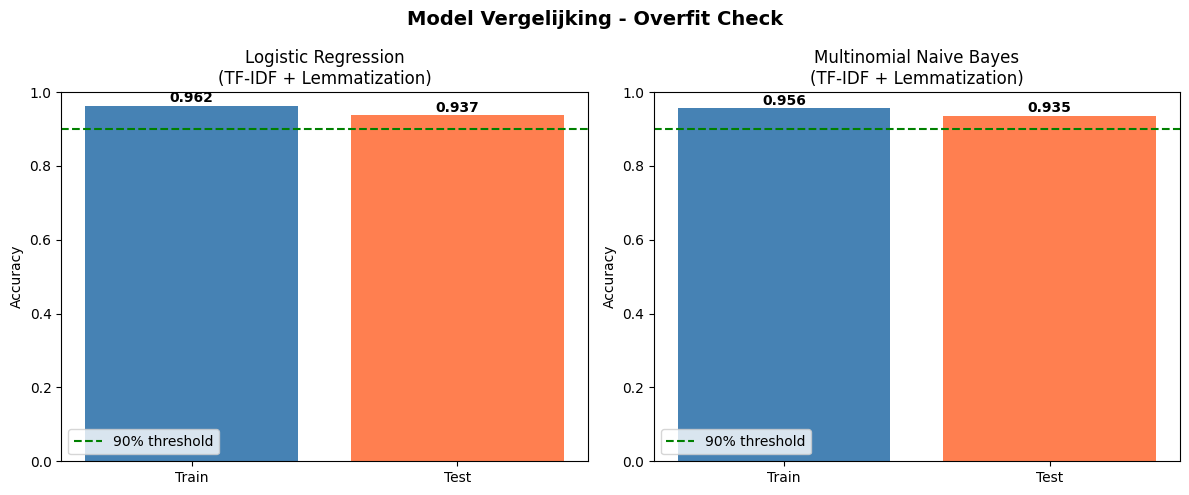

Logistic Regression → Train: 0.962 | Test: 0.937 | Verschil: 0.025
Naive Bayes         → Train: 0.956 | Test: 0.935 | Verschil: 0.021


In [80]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Logistic Regression
axes[0].bar(['Train', 'Test'], [train_acc, test_acc], color=['steelblue', 'coral'])
axes[0].set_title('Logistic Regression\n(TF-IDF + Lemmatization)')
axes[0].set_ylabel('Accuracy')
axes[0].set_ylim(0, 1)
axes[0].axhline(y=0.9, color='green', linestyle='--', label='90% threshold')
for i, v in enumerate([train_acc, test_acc]):
    axes[0].text(i, v + 0.01, f'{v:.3f}', ha='center', fontweight='bold')
axes[0].legend()

# Naive Bayes
axes[1].bar(['Train', 'Test'], [train_acc_nb, test_acc_nb], color=['steelblue', 'coral'])
axes[1].set_title('Multinomial Naive Bayes\n(TF-IDF + Lemmatization)')
axes[1].set_ylabel('Accuracy')
axes[1].set_ylim(0, 1)
axes[1].axhline(y=0.9, color='green', linestyle='--', label='90% threshold')
for i, v in enumerate([train_acc_nb, test_acc_nb]):
    axes[1].text(i, v + 0.01, f'{v:.3f}', ha='center', fontweight='bold')
axes[1].legend()

plt.suptitle('Model Vergelijking - Overfit Check', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Samenvatting
print(f'Logistic Regression → Train: {train_acc:.3f} | Test: {test_acc:.3f} | Verschil: {abs(train_acc-test_acc):.3f}')
print(f'Naive Bayes         → Train: {train_acc_nb:.3f} | Test: {test_acc_nb:.3f} | Verschil: {abs(train_acc_nb-test_acc_nb):.3f}')

In [75]:
tests = [
    "Scientists discover new medicin that could support life.",
    "WATCH NOW!!! Government hiding truth about documents!!!",
    "The president met with European leaders to discuss trade agreements.",
    "Shocking secret they don't want you to know about vaccines!!!"
]

X_new = tfidf.transform(tests)
preds = model.predict(X_new)

for text, pred in zip(tests, preds):
    print("\nTEXT:", text)
    print("VOORSPELLING:", "REAL" if pred == 1 else "FAKE")


TEXT: Scientists discover new medicin that could support life.
VOORSPELLING: FAKE

TEXT: WATCH NOW!!! Government hiding truth about documents!!!
VOORSPELLING: FAKE

TEXT: The president met with European leaders to discuss trade agreements.
VOORSPELLING: REAL

TEXT: Shocking secret they don't want you to know about vaccines!!!
VOORSPELLING: FAKE


In [76]:
import pickle

with open("model.pkl", "wb") as f:
    pickle.dump(model, f)

with open("tfidf.pkl", "wb") as f:
    pickle.dump(tfidf, f)